In [249]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix

# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)



Path to dataset files: /home/samuele/.cache/kagglehub/datasets/shauryasrivastava01/liver-patient-dataset/versions/1


In [250]:
path = "Datasets/liver_patient_dataset.csv"
df = pd.read_csv(path)

In [251]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [252]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


### Distribuzione della classe Selector (il target)

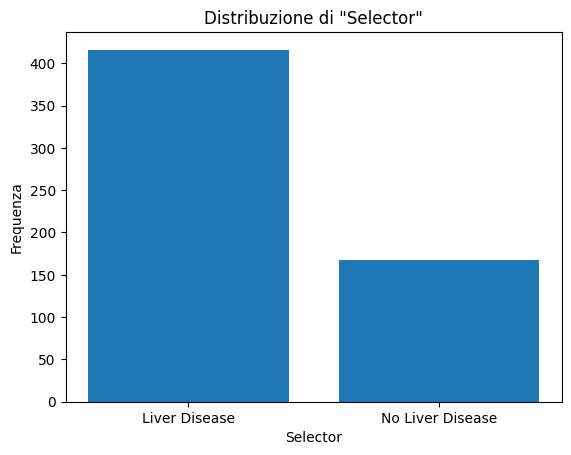

In [253]:
conteggi = df["Selector"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("Selector")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "Selector"')
plt.show()

### Creazione trainining e testing set

In [254]:
feature_names = set(df.columns) - set(["Selector"])

target_name = "Selector"

categorical_features = set(["Gender"])
continuos_features = feature_names - set(["Gender"])

print(categorical_features)
print(continuos_features)
feature_names = list(feature_names)

{'Gender'}
{'Age', 'A/G Ratio', 'Alkphos', 'Sgot', 'DB', 'ALB', 'TP', 'TB', 'Sgpt'}


In [255]:
df_encoded = df.copy()

df_encoded["Gender"] = df_encoded["Gender"].astype("category").cat.codes
df_encoded["Selector"] = df_encoded["Selector"].astype("category").cat.codes

In [256]:
df_encoded

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,1
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,0
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,0
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,0


### addestriamo IL decisione Tree

In [257]:
y = df_encoded["Selector"]
#X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [ ]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0


In [ ]:
X_train.head()

In [ ]:
y_train.head()

401    0
395    1
3      0
102    0
175    0
Name: Selector, dtype: int8

In [ ]:

model = DecisionTreeClassifier(random_state=42)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [ ]:
# [
#     true 0, false 1
#     false 0, true 1
#  ]

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[92 33]
 [32 18]]

Accuracy: 0.6285714285714286


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74       124
           1       0.36      0.35      0.36        51

    accuracy                           0.63       175
   macro avg       0.55      0.55      0.55       175
weighted avg       0.63      0.63      0.63       175



### Miglioriamo l'albero

In [ ]:
prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

In [ ]:
y_pred = prunedModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[104  21]
 [ 41   9]]

Accuracy: 0.6457142857142857


In [ ]:
#precision: Tra tutti quelli che il modello ha predetto come positivi, quanti erano davvero positivi?
#recall: Tra tutti quelli che erano davvero positivi, quanti ne ha trovati il modello?

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       145
           1       0.18      0.30      0.23        30

    accuracy                           0.65       175
   macro avg       0.51      0.51      0.50       175
weighted avg       0.72      0.65      0.68       175



### L'albero ha una bassa accuratezza, Usiamo il parametro di complessità

In [ ]:
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00204248 0.00204248 0.00210084 0.00222816 0.00222816
 0.00224673 0.00226244 0.00235486 0.00239398 0.00245098 0.0025531
 0.00326797 0.00367647 0.00367647 0.00371361 0.00420168 0.00420168
 0.00421713 0.00425099 0.0043573  0.00441176 0.00446429 0.0045098
 0.00465686 0.00485098 0.00499076 0.00526823 0.00597672 0.00640779
 0.00661765 0.00670041 0.0070028  0.00719375 0.00784032 0.00808945
 0.00837527 0.00932351 0.01163107 0.01228434 0.0142603  0.04182286]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

results = []
#andare oltre 8 lo manda comunque in overfitting

for depth in range(4, 8):
    for complexity in ccp_alphas:
        clf = DecisionTreeClassifier(
            max_depth=depth,
            ccp_alpha=complexity,
            class_weight="balanced",
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        results.append({
            "max_depth": depth,
            "ccp_alpha": complexity,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

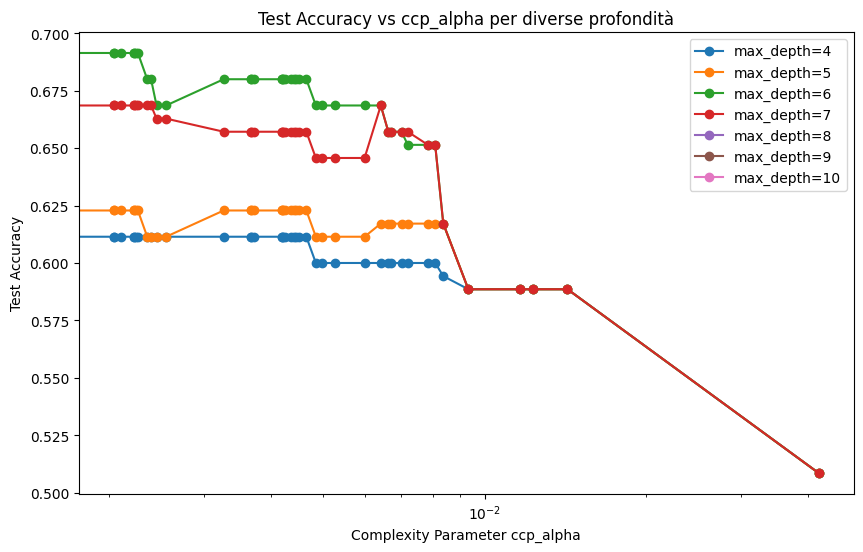

In [ ]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    test_acc = [r["test_accuracy"] for r in depth_results]

    plt.plot(alphas, test_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
best_result = max(results, key=lambda x: x["test_accuracy"])

print("Miglior max_depth:", best_result["max_depth"])
print("Miglior ccp_alpha:", best_result["ccp_alpha"])
print("Train accuracy:", best_result["train_accuracy"])
print("Test accuracy:", best_result["test_accuracy"])

Miglior max_depth: 6
Miglior ccp_alpha: 0.0
Train accuracy: 0.7745098039215687
Test accuracy: 0.6914285714285714


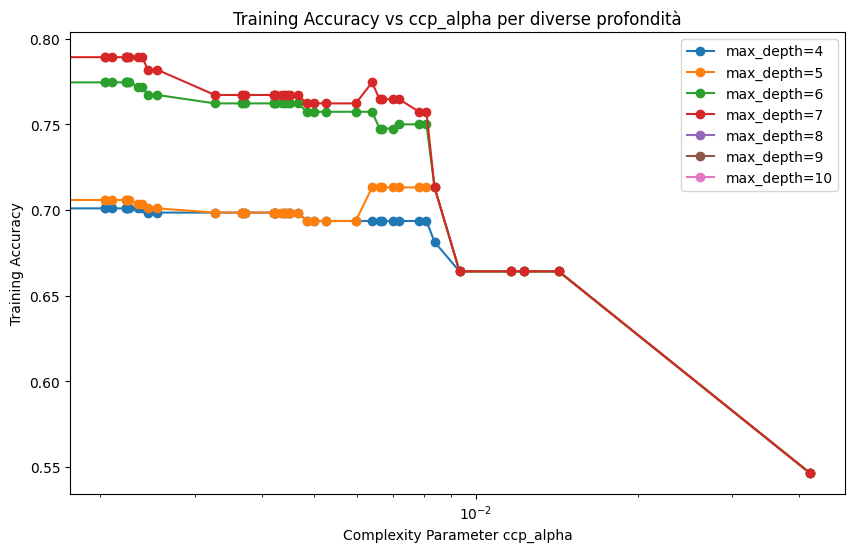

In [ ]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    train_acc = [r["train_accuracy"] for r in depth_results]

    plt.plot(alphas, train_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
best_clf = DecisionTreeClassifier(
    max_depth=best_result["max_depth"],
    ccp_alpha=best_result["ccp_alpha"],
    class_weight="balanced",
    random_state=42
)

best_clf.fit(X_train, y_train)

print("Accuracy train:", best_clf.score(X_train, y_train))
print("Accuracy test:", best_clf.score(X_test, y_test))

Accuracy train: 0.7745098039215687
Accuracy test: 0.6914285714285714


In [ ]:
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[79 46]
 [ 8 42]]

Accuracy: 0.6914285714285714


In [ ]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.63      0.91      0.75        87
           1       0.84      0.48      0.61        88

    accuracy                           0.69       175
   macro avg       0.74      0.69      0.68       175
weighted avg       0.74      0.69      0.68       175



### diamo un occhiata con la balancedPrecision

In [ ]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.63      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.69       175
   macro avg       0.69      0.74      0.68       175
weighted avg       0.78      0.69      0.71       175

Balanced accuracy: 0.736
[[79 46]
 [ 8 42]]


### Andiamo a modificare l'addestramento per dare più peso ai dati minoritari

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try=None,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    pos_label=1,
    random_state=42,
    print_report=True
):
    """
    Addestra più DecisionTreeClassifier provando:
    - diverse profondità;
    - diversi valori di ccp_alpha;
    - diversi pesi manuali per le classi.

    Restituisce:
    - best_clf: modello migliore riaddestrato;
    - results_df: DataFrame con tutti i risultati;
    - best_row: riga del DataFrame corrispondente al miglior modello.
    """

    if weights_to_try is None:
        weights_to_try = [
            {0: 1, 1: 1},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5},
            {0: 1, 1: 10}
        ]

    results = []

    for depth in depths:
        for complexity in ccp_alphas:
            for weights in weights_to_try:

                clf = DecisionTreeClassifier(
                    max_depth=depth,
                    ccp_alpha=complexity,
                    class_weight=weights,
                    random_state=random_state
                )

                clf.fit(X_train, y_train)

                y_pred_train = clf.predict(X_train)
                y_pred_test = clf.predict(X_test)

                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
                test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

                precision_1 = precision_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                recall_1 = recall_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                f1_1 = f1_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="weighted",
                    zero_division=0
                )

                results.append({
                    "max_depth": depth,
                    "ccp_alpha": complexity,
                    "class_weight": weights,
                    "weight_0": weights.get(0, np.nan),
                    "weight_1": weights.get(1, np.nan),

                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,

                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,

                    "precision_class_1": precision_1,
                    "recall_class_1": recall_1,
                    "f1_class_1": f1_1,

                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

    results_df = pd.DataFrame(results)

    if scoring_metric not in results_df.columns:
        raise ValueError(
            f"scoring_metric non valido: {scoring_metric}. "
            f"Scegli tra: {list(results_df.columns)}"
        )

    best_index = results_df[scoring_metric].idxmax()
    best_row = results_df.loc[best_index]

    best_clf = DecisionTreeClassifier(
        max_depth=int(best_row["max_depth"]),
        ccp_alpha=best_row["ccp_alpha"],
        class_weight=best_row["class_weight"],
        random_state=random_state
    )

    best_clf.fit(X_train, y_train)

    y_pred_best = best_clf.predict(X_test)

    if print_report:
        print("Migliore configurazione trovata:")
        print(best_row)

        print("\nConfusion matrix:")
        print(confusion_matrix(y_test, y_pred_best))

        print("\nClassification report:")
        print(classification_report(y_test, y_pred_best, zero_division=0))

    return best_clf, results_df, best_row

In [ ]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 4.5},
    {0: 1, 1: 5},
    {0: 1, 1: 7},
    {0: 1, 1: 9},
    {0: 1, 1: 10}
]

best_clf, results_df, best_row = train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1"
)


Migliore configurazione trovata:
max_depth                             7
ccp_alpha                           0.0
class_weight               {0: 1, 1: 4}
weight_0                              1
weight_1                            4.0
train_accuracy                 0.776961
test_accuracy                  0.697143
train_balanced_accuracy        0.843643
test_balanced_accuracy             0.74
precision_class_1              0.482759
recall_class_1                     0.84
f1_class_1                     0.613139
macro_f1                       0.682156
weighted_f1                    0.711735
Name: 1391, dtype: object

Confusion matrix:
[[80 45]
 [ 8 42]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.64      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.70       175
   macro avg       0.70      0.74      0.68       175
weighted avg       0.79      0.70      0.71    

In [ ]:
y_pred_test = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.91      0.64      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.70       175
   macro avg       0.70      0.74      0.68       175
weighted avg       0.79      0.70      0.71       175



### Facciamo un ensemble a majority

In [ ]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
def majority_vote(predictions):
    """
    predictions deve essere una lista con 3 array.

    Esempio:
    predictions = [
        predizioni_modello_1,
        predizioni_modello_2,
        predizioni_modello_3
    ]

    Ogni array contiene valori 0/1.
    """

    final_predictions = []

    n_samples = len(predictions[0])

    for i in range(n_samples):
        votes_for_1 = 0

        for model_predictions in predictions:
            if model_predictions[i] == 1:
                votes_for_1 = votes_for_1 + 1

        if votes_for_1 >= 2:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


def train_three_trees(
    X_train,
    y_train,
    max_depth,
    ccp_alpha,
    class_weight,
    random_state=42
):
    models = []

    splitter = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    fold_number = 0

    for train_index, part_index in splitter.split(X_train, y_train):
        X_part = X_train.iloc[part_index]
        y_part = y_train.iloc[part_index]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )

        tree.fit(X_part, y_part)

        models.append(tree)

        fold_number = fold_number + 1

    return models
def predict_ensemble(models, X_test):
    predictions = []

    for model in models:
        model_predictions = model.predict(X_test)
        predictions.append(model_predictions)

    final_predictions = majority_vote(predictions)

    return final_predictions

def search_best_ensemble_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_models = None
    best_score = -1
    best_row = None
    best_predictions = None

    for depth in depths:

        for alpha in ccp_alphas:

            for weights in weights_to_try:

                models = train_three_trees(
                    X_train=X_train,
                    y_train=y_train,
                    max_depth=depth,
                    ccp_alpha=alpha,
                    class_weight=weights,
                    random_state=random_state
                )

                y_pred = predict_ensemble(
                    models=models,
                    X_test=X_test
                )

                test_accuracy = accuracy_score(y_test, y_pred)

                test_balanced_accuracy = balanced_accuracy_score(
                    y_test,
                    y_pred
                )

                precision_class_1 = precision_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                recall_class_1 = recall_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                f1_class_1 = f1_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                row = {
                    "max_depth": depth,
                    "ccp_alpha": alpha,
                    "class_weight": weights,
                    "weight_0": weights[0],
                    "weight_1": weights[1],
                    "test_accuracy": test_accuracy,
                    "test_balanced_accuracy": test_balanced_accuracy,
                    "precision_class_1": precision_class_1,
                    "recall_class_1": recall_class_1,
                    "f1_class_1": f1_class_1,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_models = models
                    best_row = row
                    best_predictions = y_pred

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    print("Metrica usata per scegliere:", scoring_metric)
    print("Valore migliore:", best_score)

    return best_models, results_df, best_row, best_predictions


In [ ]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 5}, 'weight_0': 1, 'weight_1': 5, 'test_accuracy': 0.6057142857142858, 'test_balanced_accuracy': 0.706, 'precision_class_1': 0.415929203539823, 'recall_class_1': 0.94, 'f1_class_1': 0.5766871165644172, 'macro_f1': 0.603851579672583, 'weighted_f1': 0.6154934924332254}

Confusion matrix:
[[59 66]
 [ 3 47]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.47      0.63       125
           1       0.42      0.94      0.58        50

    accuracy                           0.61       175
   macro avg       0.68      0.71      0.60       175
weighted avg       0.80      0.61      0.62       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.5766871165644172


In [ ]:
results_df.sort_values(
    by="f1_class_1",
    ascending=False
).head(10)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,test_accuracy,test_balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1
433,5,0.004251,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
377,5,0.002553,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
370,5,0.002451,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
447,5,0.004412,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
454,5,0.004464,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
426,5,0.004217,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
440,5,0.004357,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
384,5,0.003268,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
363,5,0.002394,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
391,5,0.003676,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493


In [ ]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.47      0.63       125
           1       0.42      0.94      0.58        50

    accuracy                           0.61       175
   macro avg       0.68      0.71      0.60       175
weighted avg       0.80      0.61      0.62       175



### proviamo  a fare undersampling del dataframe

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


def train_test_split_with_undersampling(
    df,
    target_col,
    test_size=0.3,
    random_state=42,
    stratify=True
):
    """
    Divide il DataFrame in train/test e applica undersampling solo al training set.

    Parametri:
    - df: DataFrame completo
    - target_col: nome della colonna target, esempio "Selector"
    - test_size: percentuale del test set
    - random_state: seed per riproducibilità
    - stratify: se True, mantiene proporzioni simili delle classi nello split

    Ritorna:
    - X_train_under
    - X_test
    - y_train_under
    - y_test
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    if stratify:
        stratify_values = y
    else:
        stratify_values = None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_values
    )

    train_df = X_train.copy()
    train_df[target_col] = y_train

    class_counts = train_df[target_col].value_counts()
    min_class_count = class_counts.min()

    undersampled_parts = []

    for class_value in class_counts.index:
        class_df = train_df[train_df[target_col] == class_value]

        class_df_under = class_df.sample(
            n=min_class_count,
            random_state=random_state
        )

        undersampled_parts.append(class_df_under)

    train_df_under = pd.concat(undersampled_parts)

    train_df_under = train_df_under.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    X_train_under = train_df_under.drop(columns=[target_col])
    y_train_under = train_df_under[target_col]

    return X_train_under, X_test, y_train_under, y_test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df=df_encoded,
    target_col="Selector",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [ ]:
y_train.value_counts()

Selector
0    120
1    120
Name: count, dtype: int64

In [ ]:
X_test.count()

Age          175
Gender       175
TB           175
DB           175
Alkphos      175
Sgpt         175
Sgot         175
TP           175
ALB          175
A/G Ratio    175
dtype: int64

In [ ]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1.5}, 'weight_0': 1, 'weight_1': 1.5, 'test_accuracy': 0.6914285714285714, 'test_balanced_accuracy': 0.7755984042553192, 'precision_class_1': 0.4639175257731959, 'recall_class_1': 0.9574468085106383, 'f1_class_1': 0.625, 'macro_f1': 0.6814320388349515, 'weighted_f1': 0.7075520110957004}

Confusion matrix:
[[76 52]
 [ 2 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.625


In [ ]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175



### Usiamo le random forests

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try,
    depths_to_try,
    weights_to_try,
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_model = None
    best_score = -1
    best_row = None
    best_predictions = None

    for n_estimators in n_estimators_to_try:
        for max_depth in depths_to_try:
            for weights in weights_to_try:

                rf = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    class_weight=weights,
                    random_state=random_state,
                    n_jobs=-1
                )

                rf.fit(X_train, y_train)

                y_pred_train = rf.predict(X_train)
                y_pred_test = rf.predict(X_test)

                row = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "class_weight": weights,
                    "weight_0": weights[0] if isinstance(weights, dict) else None,
                    "weight_1": weights[1] if isinstance(weights, dict) else None,

                    "train_accuracy": accuracy_score(y_train, y_pred_train),
                    "test_accuracy": accuracy_score(y_test, y_pred_test),
                    "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),

                    "precision_class_1": precision_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "recall_class_1": recall_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "f1_class_1": f1_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "macro_f1": f1_score(
                        y_test,
                        y_pred_test,
                        average="macro",
                        zero_division=0
                    )
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_model = rf
                    best_row = row
                    best_predictions = y_pred_test

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    return best_model, results_df, best_row, best_predictions

In [ ]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try=n_estimators_to_try,
    depths_to_try=depths_to_try,
    weights_to_try=weights_to_try,
    scoring_metric="macro_f1"
)

In [ ]:
best_rf.fit(X_train, y_train)

y_pred_test = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

NameError: name 'best_rf' is not defined